In [1]:
import os
import cv2
import pydicom
import pandas as pd
import numpy as np 
import tensorflow as tf 
import random

from tqdm.notebook import tqdm 
from typing import Sequence
import efficientnet.tfkeras as efn
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from PIL import Image
import h5py
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Dense, Dropout, Activation, Flatten, Input, BatchNormalization, GlobalAveragePooling2D, Add, Conv2D, AveragePooling2D, 
    LeakyReLU, Concatenate 
)
from tensorflow.keras import Model


0it [00:00, ?it/s]

A_slope: {'ID00007637202177411956430': -3.1671258700696026, 'ID00009637202177434476278': -9.379955123410637, 'ID00010637202177584971671': -17.04280323873905, 'ID00011637202177653955184': -4.5489251297257445, 'ID00012637202177665765362': -8.54307852898669, 'ID00014637202177757139317': -14.033411631297666, 'ID00015637202177877247924': -7.578959348113091, 'ID00019637202178323708467': -5.7299607299607045, 'ID00020637202178344345685': -7.370692539310823, 'ID00023637202179104603099': -2.549151772190275, 'ID00025637202179541264076': -10.81815281544106, 'ID00026637202179561894768': -2.9678593086719505, 'ID00027637202179689871102': -5.4943685597891205, 'ID00030637202181211009029': -4.687772738940666, 'ID00032637202181710233084': -14.362868550368603, 'ID00035637202182204917484': -9.673158832184635, 'ID00038637202182690843176': -0.8007971241012665, 'ID00042637202184406822975': 0.5981338481338551, 'ID00047637202184938901501': -10.831542461005142, 'ID00048637202185016727717': -1.1904083570750204, '

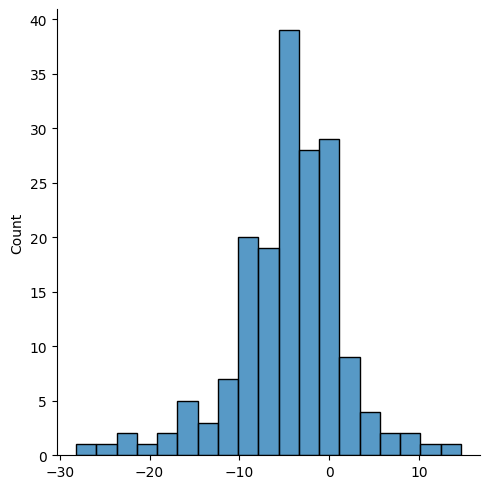

Number of unique patient identifiers in the test set: 5
Processing Patient ID: ID00224637202259281193413
2/2 [==============================] - 8s 642ms/step



model Value??? [[0.02823764]
 [0.02823798]
 [0.0282376 ]
 [0.02823958]
 [0.02823779]
 [0.02823805]
 [0.02824066]
 [0.02823831]
 [0.02823847]
 [0.02824049]
 [0.02823799]
 [0.028238  ]
 [0.02823856]
 [0.02823859]
 [0.02824006]
 [0.02823951]
 [0.02824085]
 [0.02823826]
 [0.02824022]
 [0.0282402 ]
 [0.02823931]
 [0.02823936]
 [0.02823753]
 [0.02823787]
 [0.02824005]
 [0.02823669]
 [0.02823935]
 [0.02823829]
 [0.02823672]
 [0.02823991]
 [0.02823755]
 [0.02823786]
 [0.02823799]
 [0.02823874]
 [0.02823663]]
35


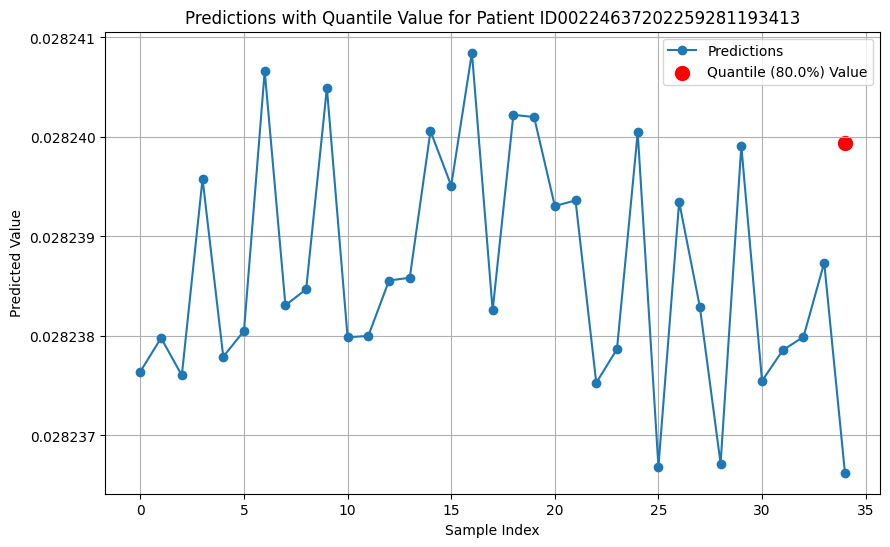

Processing Patient ID: ID00285637202278913507108
1/1 [==============================] - 4s 4s/step



model Value??? [[0.02411525]
 [0.02411544]
 [0.02411519]
 [0.02411466]
 [0.02411427]
 [0.02411421]
 [0.02411465]
 [0.02411431]
 [0.02411433]
 [0.0241144 ]
 [0.02411471]
 [0.02411455]
 [0.02411457]
 [0.02411546]
 [0.02411522]
 [0.02411556]
 [0.02411573]
 [0.02411508]
 [0.02411532]
 [0.02411509]]
20


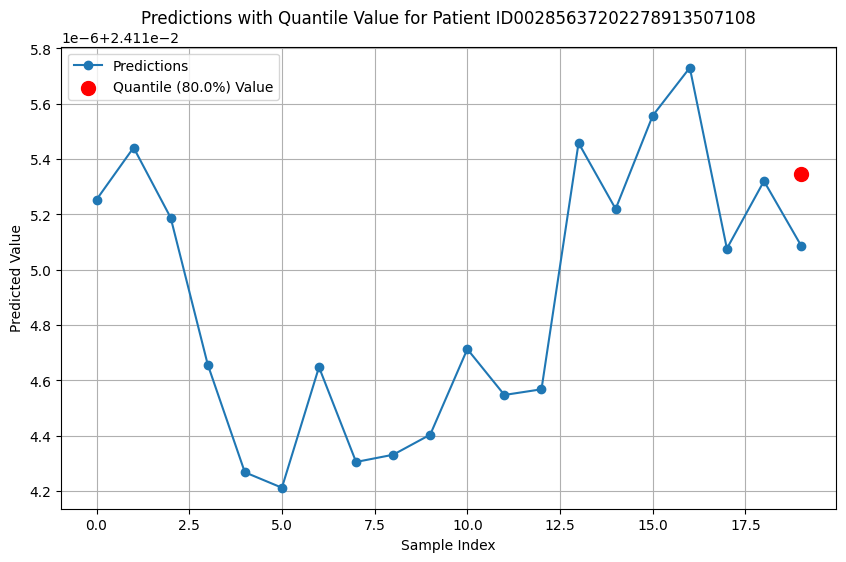

Processing Patient ID: ID00051637202185848464638
3/3 [==============================] - 15s 4s/step



model Value??? [[0.06326818]
 [0.06326805]
 [0.06326773]
 [0.06326804]
 [0.0632683 ]
 [0.06326838]
 [0.06326802]
 [0.06326805]
 [0.06326891]
 [0.06326824]
 [0.06326824]
 [0.06326822]
 [0.06326807]
 [0.06326799]
 [0.0632684 ]
 [0.06326827]
 [0.06326909]
 [0.06326827]
 [0.06326791]
 [0.06326853]
 [0.0632679 ]
 [0.06326856]
 [0.06326836]
 [0.06326851]
 [0.06326846]
 [0.06326808]
 [0.06326819]
 [0.06326798]
 [0.06326825]
 [0.06326818]
 [0.06326833]
 [0.06326851]
 [0.06326821]
 [0.06326831]
 [0.06326796]
 [0.06326784]
 [0.06326775]
 [0.06326807]
 [0.06326842]
 [0.06326772]
 [0.06326807]
 [0.06326817]
 [0.06326769]
 [0.06326813]
 [0.06326806]
 [0.06326777]
 [0.0632681 ]
 [0.06326826]
 [0.06326811]
 [0.06326795]
 [0.06326786]
 [0.06326833]
 [0.0632683 ]
 [0.06326785]
 [0.06326813]
 [0.06326805]
 [0.0632686 ]
 [0.0632686 ]
 [0.06326783]
 [0.06326786]
 [0.06326811]
 [0.06326832]
 [0.06326795]


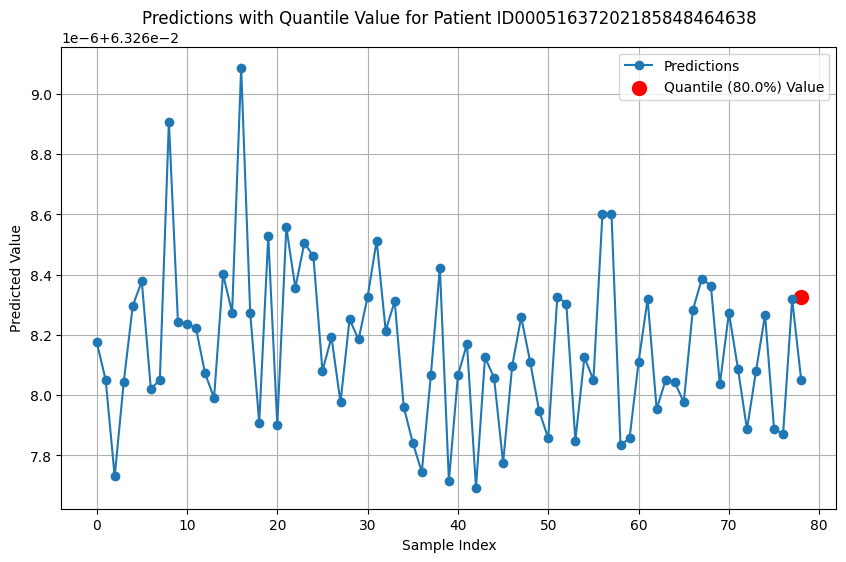

Processing Patient ID: ID00168637202237852027833
6/6 [==============================] - 30s 5s/step



model Value??? [[0.05914664]
 [0.0591475 ]
 [0.0591476 ]
 [0.05914677]
 [0.05914729]
 [0.05914772]
 [0.05914645]
 [0.05914682]
 [0.05914751]
 [0.05914715]
 [0.05914655]
 [0.05914721]
 [0.05914703]
 [0.05914687]
 [0.05914702]
 [0.05914669]
 [0.05914709]
 [0.0591468 ]
 [0.05914725]
 [0.0591476 ]
 [0.05914785]
 [0.05914743]
 [0.05914638]
 [0.05914652]
 [0.05914682]
 [0.05914702]
 [0.05914836]
 [0.05914889]
 [0.05914916]
 [0.05914869]
 [0.05914848]
 [0.05914705]
 [0.05914684]
 [0.05914651]
 [0.05914634]
 [0.05914876]
 [0.05914628]
 [0.05914668]
 [0.0591485 ]
 [0.05914713]
 [0.0591483 ]
 [0.05914906]
 [0.05914891]
 [0.05914845]
 [0.05914864]
 [0.05914722]
 [0.05914672]
 [0.05914848]
 [0.05914601]
 [0.05914643]
 [0.05914896]
 [0.05914668]
 [0.05914897]
 [0.05914845]
 [0.05914612]
 [0.05914848]
 [0.05914606]
 [0.05914907]
 [0.05914916]
 [0.0591463 ]
 [0.05914669]
 [0.05914649]
 [0.05914646]


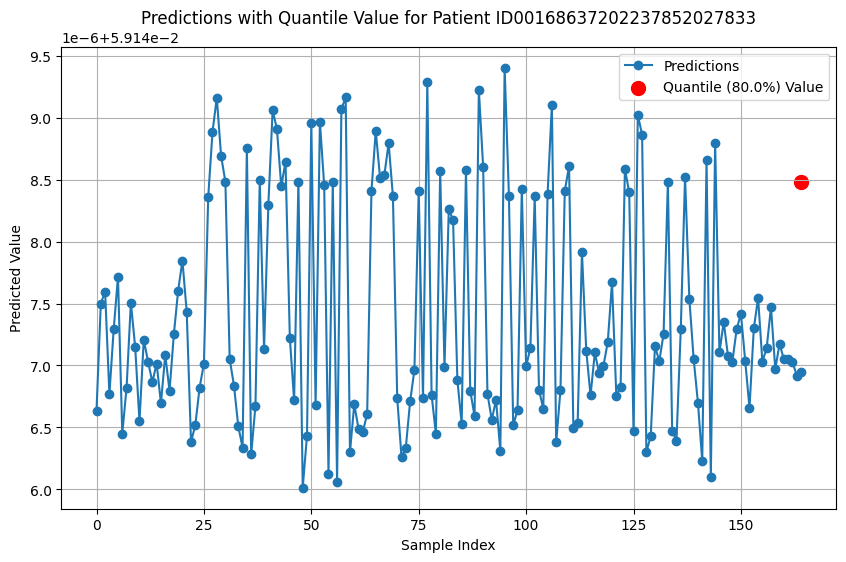

Processing Patient ID: ID00127637202219096738943
1/1 [==============================] - 6s 6s/step



model Value??? [[0.05652574]
 [0.05652566]
 [0.05652534]
 [0.05652449]
 [0.05652551]
 [0.05652469]
 [0.05652524]
 [0.05652514]
 [0.05652581]
 [0.05652581]
 [0.05652487]
 [0.0565249 ]
 [0.05652507]
 [0.05652591]
 [0.05652492]
 [0.05652462]
 [0.05652535]
 [0.05652438]
 [0.05652528]
 [0.05652477]
 [0.05652434]
 [0.05652479]
 [0.05652521]
 [0.05652434]
 [0.05652479]
 [0.0565253 ]
 [0.05652456]
 [0.05652496]
 [0.05652431]
 [0.05652557]
 [0.05652513]
 [0.05652522]]
32


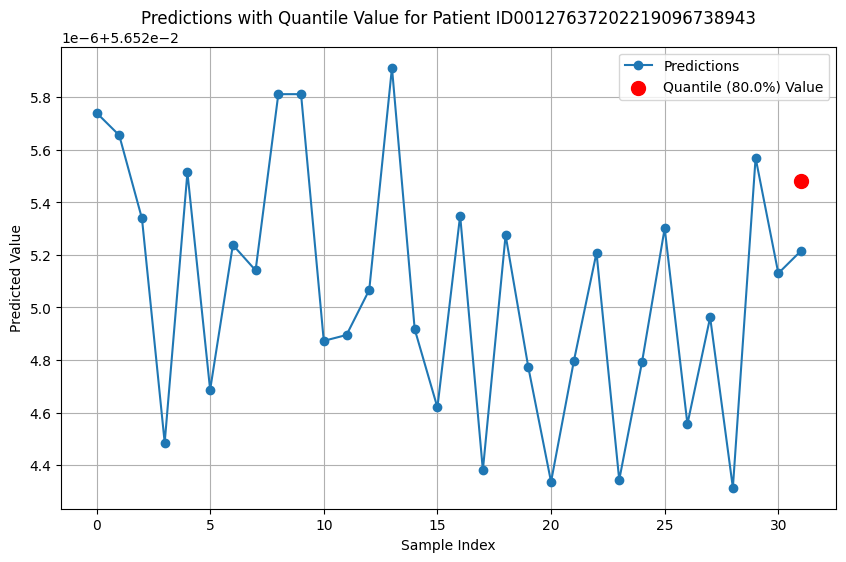

0      2810.107924
1      1302.311926
2      1527.824290
3      2706.741309
4      1544.669146
          ...     
725    2814.202715
726    1305.808651
727    1536.998198
728    2715.317839
729    1552.865341
Name: FVC, Length: 730, dtype: float64


/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_44467/1259523278.py:310: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2810.10792424]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_44467/1259523278.py:311: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[58.2653776]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'Confidence'] = (


In [3]:
# Function to set seed for reproducibility(random number generator)

def seed_everything(seed=2020):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_everything(42)

# Configuration for TensorFlow session
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

#supress tensorflow addons warning

train = pd.read_csv('osic-pulmonary-fibrosis-progression/train.csv') 

def get_tab(df):
    # age (calculated closer to 0-1)
    vector = [(df.Age.values[0] - 30) / 30] 
    
    # male:0, female: 1
    if df.Sex.values[0] == 'male':
       vector.append(0)
    else:
       vector.append(1)
    
    # never smoked: 0, 0/ex-smoker: 1,1/currently: 0,1
    if df.SmokingStatus.values[0] == 'Never smoked':
        vector.extend([0,0])
    elif df.SmokingStatus.values[0] == 'Ex-smoker':
        vector.extend([1,1])
    elif df.SmokingStatus.values[0] == 'Currently smokes':
        vector.extend([0,1])
    else:
        vector.extend([1,0])

    return np.array(vector) 

A_slope = {} # computed value (slope'a') for each patient
TAB = {} # tabular data for each patient
P = [] # unique patient identifiers
# save patient-specific datasets/linear regression

for i, p in tqdm(enumerate(train.Patient.unique())):
    sub = train.loc[train.Patient == p, :] 
    fvc = sub.FVC.values
    weeks = sub.Weeks.values
    c = np.vstack([weeks, np.ones(len(weeks))]).T
    a, b = np.linalg.lstsq(c, fvc, rcond=None)[0] #fvc=a*weeks+b
    # a = how much FVC changes per week
    # b = constant (0), not used for this
    
    A_slope[p] = a
    TAB[p] = get_tab(sub)
    P.append(p)

print("A_slope:", A_slope)
print("TAB:", TAB)
print("Amount of Patient identifier:", len(P))

# read DICOM, normalized
def get_img(path):
    d = pydicom.dcmread(path)
    return cv2.resize(d.pixel_array / 2**11, (512, 512))

# Class for creating a custom batch generator
# class IGenerator(Sequence):
#     BAD_ID = ['ID00011637202177653955184', 'ID00052637202186188008618']
#     def __init__(self, keys, a, tab, batch_size=128):
#         self.keys = [k for k in keys if k not in self.BAD_ID]
#         self.a = a
#         self.tab = tab
#         self.batch_size = batch_size
        
#         self.train_data = {}
#         for p in train.Patient.values:
#             self.train_data[p] = os.listdir(f'osic-pulmonary-fibrosis-progression/train/{p}/')
        
#     def __len__(self):
#         return 1000
    
#     def __getitem__(self, idx):
#         x = [] # DICOM file appends
#         a, tab = [], [] 
#         keys = np.random.choice(self.keys, size = self.batch_size)
#         for k in keys:
#             try:
#                 i = np.random.choice(self.train_data[k], size=1)[0]
#                 img = get_img(f'osic-pulmonary-fibrosis-progression/train/{k}/{i}')
#                 x.append(img)
#                 a.append(self.a[k])
#                 tab.append(self.tab[k])
#             except:
#                 print(k, i)
       
#         x,a,tab = np.array(x), np.array(a), np.array(tab)
#         x = np.expand_dims(x, axis=-1)
#         print(f"Batch {idx}: Number of images = {len(x)}, Number of 'a' values = {len(a)}, Number of tabular data entries = {len(tab)}")

#         return [x, tab] , a



def get_efficientnet(model, shape):
    models_dict = {
        'b0': efn.EfficientNetB0(input_shape=shape,weights=None,include_top=False),
        'b1': efn.EfficientNetB1(input_shape=shape,weights=None,include_top=False),
        'b2': efn.EfficientNetB2(input_shape=shape,weights=None,include_top=False),
        'b3': efn.EfficientNetB3(input_shape=shape,weights=None,include_top=False),
        'b4': efn.EfficientNetB4(input_shape=shape,weights=None,include_top=False),
        'b5': efn.EfficientNetB5(input_shape=shape,weights=None,include_top=False),
        'b6': efn.EfficientNetB6(input_shape=shape,weights=None,include_top=False),
        'b7': efn.EfficientNetB7(input_shape=shape,weights=None,include_top=False)
    }
    return models_dict[model]



# Function to build the model
def build_model(shape=(512, 512, 1), model_class=None):
    inp = Input(shape=shape) #image data
    base = get_efficientnet(model_class, shape)
    x = base(inp)
    x = GlobalAveragePooling2D()(x) #reduce dimensionality

    x_shape = x.shape  # Get the shape of x
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length
    
    x = Dropout(0.5)(x)  #prevent overfitting, usually 0.3-0.5
    print("Shape of 'x' tensor after dropout:", x.shape)  # Print the shape instead of length

    # x_shape, x2_shape: number of elements in the vector

    inp2 = Input(shape=(4,)) #tabulr data
    x2 = tf.keras.layers.GaussianNoise(0.2)(inp2)
    x2_shape = x2.shape  # Get the shape of x2
    print("Shape of 'x2' tensor:", x2_shape)  # Print the shape instead of length

    x = Concatenate()([x, x2]) 
    x_shape = x.shape  # Get the shape of x
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length

    
    # What's the default to dropout

    x = Dense(1)(x)
    x_shape = x.shape  # Get the shape of x
    
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length

    print("Final value of 'x':", x)

    model = Model([inp, inp2] , x)

    return model

# Model classes to build
model_classes = ['b5'] #['b0','b1','b2','b3',b4','b5','b6','b7']

# Initialize your models here
models = [build_model(shape=(512, 512, 1), model_class=m) for m in model_classes]
print("This is model")
print(models)

# Directory to save the weights
weights_directory = 'osic_model_weights'

# Ensure the directory exists
os.makedirs(weights_directory, exist_ok=True)

# Function to generate random weights
def generate_weights(model, model_class):
    # Generate random weights
    weights = [np.random.randn(*w.shape) for w in model.get_weights()]
    
    # Save weights to HDF5 file
    with h5py.File(os.path.join(weights_directory, f'{model_class}.h5'), 'w') as f:
        for i, w in enumerate(weights):
            f.create_dataset(f'weight_{i}', data=w)

# Generate weights for each model
for model, model_class in zip(models, model_classes):
    generate_weights(model, model_class)

print("\nWeights generated successfully.")
print('Number of models: ' + str(len(models)))

tr_p, vl_p = train_test_split(P, 
                              shuffle=True, 
                              train_size= 0.8) 
print("Number of patient identifiers in training set (tr_p):", len(tr_p))
print("Number of patient identifiers in validation set (vl_p):", len(vl_p))

sns.displot(list(A_slope.values()))
plt.show()

# Caculate the score
def score(fvc_true, fvc_pred, sigma):
    sigma_clip = np.maximum(sigma, 70) # changed from 70, trie 66.7 too
    delta = np.abs(fvc_true - fvc_pred)
    delta = np.minimum(delta, 1000)
    sq2 = np.sqrt(2)
    metric = (delta / sigma_clip)*sq2 + np.log(sigma_clip* sq2)
    return np.mean(metric)


subs = []
for model in models:
    metric = []
    # for q in tqdm(range(1, 10)):
        # m = []
        # for p in vl_p:
        #     x = [] 
        #     tab = [] 

            # if p in ['ID00011637202177653955184', 'ID00052637202186188008618']:
            #     continue

        #     ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/train/{p}/')
        #     for i in ldir:
        #         if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
        #             x.append(get_img(f'osic-pulmonary-fibrosis-progression/train/{p}/{i}')) 
        #             tab.append(get_tab(train.loc[train.Patient == p, :])) 
        #     if len(x) < 1:
        #         continue
        #     tab = np.array(tab) 

        #     x = np.expand_dims(x, axis=-1) 
        #     _a = model.predict([x, tab]) 
        #     a = np.quantile(_a, q / 10)

        #     percent_true = train.Percent.values[train.Patient == p]
        #     fvc_true = train.FVC.values[train.Patient == p]
        #     weeks_true = train.Weeks.values[train.Patient == p]

        #     fvc = a * (weeks_true - weeks_true[0]) + fvc_true[0]
        #     percent = percent_true[0] - a * abs(weeks_true - weeks_true[0])
        #     m.append(score(fvc_true, fvc, percent))
        #     mean_metric=np.mean(m)
        #     print(f"Model: {model_classes[models.index(model)]}, Quantile: {q/10}, Mean Metric: {mean_metric}")
        # print(np.mean(m))
        # metric.append(np.mean(m))

    #q = (np.argmin(metric) + 1)/ 10
    q=0.8
    sub = pd.read_csv('osic-pulmonary-fibrosis-progression/sample_submission.csv') 
    test = pd.read_csv('osic-pulmonary-fibrosis-progression/test.csv') 
    P_test = test.Patient.unique()

    print("Number of unique patient identifiers in the test set:", len(P_test))

    A_test, B_test, P_test,W, FVC= {}, {}, {},{},{} 
    STD, WEEK = {}, {} 
    quantile_values = []

    for p in test.Patient.unique():
        x = [] 
        tab = [] 
        ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/test/{p}/')
        print(f"Processing Patient ID: {p}")

        for i in ldir:
            if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
                x.append(get_img(f'osic-pulmonary-fibrosis-progression/test/{p}/{i}')) 
                tab.append(get_tab(test.loc[test.Patient == p, :])) 
        if len(x) <= 1:
            continue
        tab = np.array(tab) 

        x = np.expand_dims(x, axis=-1) 
        _a = model.predict([x, tab]) 
        print('\n\n\nmodel Value??? ' + str(_a))

        a = np.quantile(_a, q)
        quantile_values.append(a)

        num_elements = _a.size
        print(num_elements)


        plt.figure(figsize=(10, 6))
        plt.plot(_a, marker='o', label='Predictions')
        # Highlighting the quantile value on the plot
        plt.scatter(len(_a)-1, a, color='red', s=100, label=f'Quantile ({q * 100}%) Value')
        plt.title(f'Predictions with Quantile Value for Patient {p}')
        plt.xlabel('Sample Index')
        plt.ylabel('Predicted Value')
        plt.grid(True)
        plt.legend()
        plt.show()




        A_test[p] = a
        B_test[p] = test.FVC.values[test.Patient == p] - a*test.Weeks.values[test.Patient == p]
        P_test[p] = test.Percent.values[test.Patient == p] 
        WEEK[p] = test.Weeks.values[test.Patient == p]

    for k in sub.Patient_Week.values:
        # p=patiehtnID
        # w=week to predict
        p, w = k.split('_')
        w = int(w) 
        fvc = A_test[p] * w + B_test[p] 

        # b
        sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
        sub.loc[sub.Patient_Week == k, 'Confidence'] = (
            P_test[p] - A_test[p] * abs(WEEK[p] - w) 
            # P_test[p]: % predicted FVC
            # A_test[p]: predicted change in FVC per week for patient p
            # WEEK[p]: initial week
            )
         
    sub.to_csv('sub.csv', index=False)
    _sub = sub[["Patient_Week","FVC","Confidence"]].copy()
    subs.append(_sub)

N = len(subs)
sub = subs[0].copy() # ref
sub["FVC"] = 0
sub["Confidence"] = 0
for i in range(N):
    sub["FVC"] += subs[i]["FVC"] * (1/N)
    print(sub["FVC"])
    sub["Confidence"] += subs[i]["Confidence"] * (1/N)

sub[["Patient_Week","FVC","Confidence"]].to_csv("submission_img.csv", index=False)
